Predicted class: 5

CNN Summary:
conv1 | Conv2d | Input: [1, 1, 28, 28] | Output: [1, 32, 28, 28] | Kernel: (3, 3) | Stride: (1, 1) | Padding: (1, 1)
conv2 | Conv2d | Input: [1, 32, 28, 28] | Output: [1, 64, 28, 28] | Kernel: (3, 3) | Stride: (1, 1) | Padding: (1, 1)
pool | MaxPool2d | Input: [1, 64, 28, 28] | Output: [1, 64, 14, 14] | Kernel: 2 | Stride: 2 | Padding: 0
dropout1 | Dropout | Input: [1, 64, 14, 14] | Output: [1, 64, 14, 14] | Kernel: - | Stride: - | Padding: -
fc1 | Linear | Input: [1, 64, 14, 14] | Output: [1, 128] | Kernel: - | Stride: - | Padding: -
dropout2 | Dropout | Input: [1, 128] | Output: [1, 128] | Kernel: - | Stride: - | Padding: -
fc2 | Linear | Input: [1, 128] | Output: [1, 10] | Kernel: - | Stride: - | Padding: -
relu | ReLU | Input: [1, 10] | Output: [1, 10] | Kernel: - | Stride: - | Padding: -


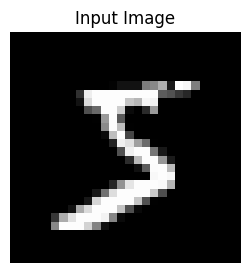

dict_keys(['conv1', 'conv2', 'pool'])


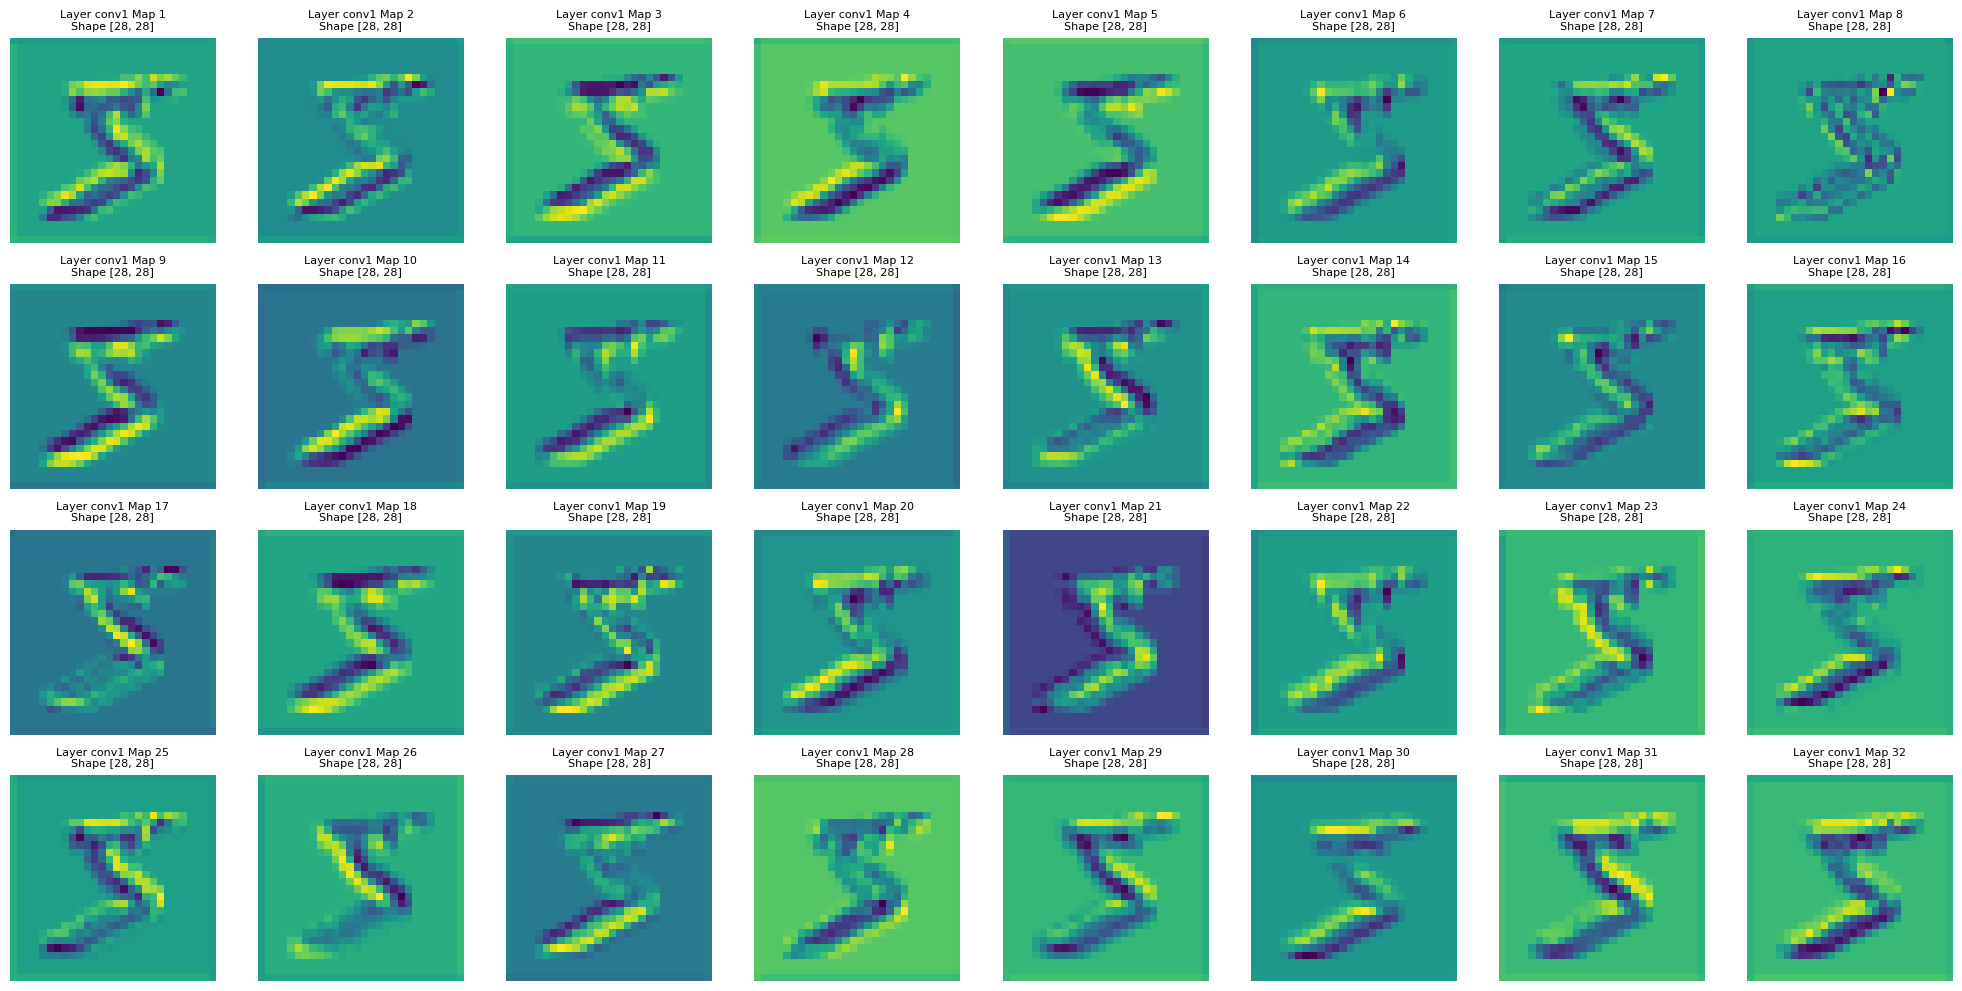

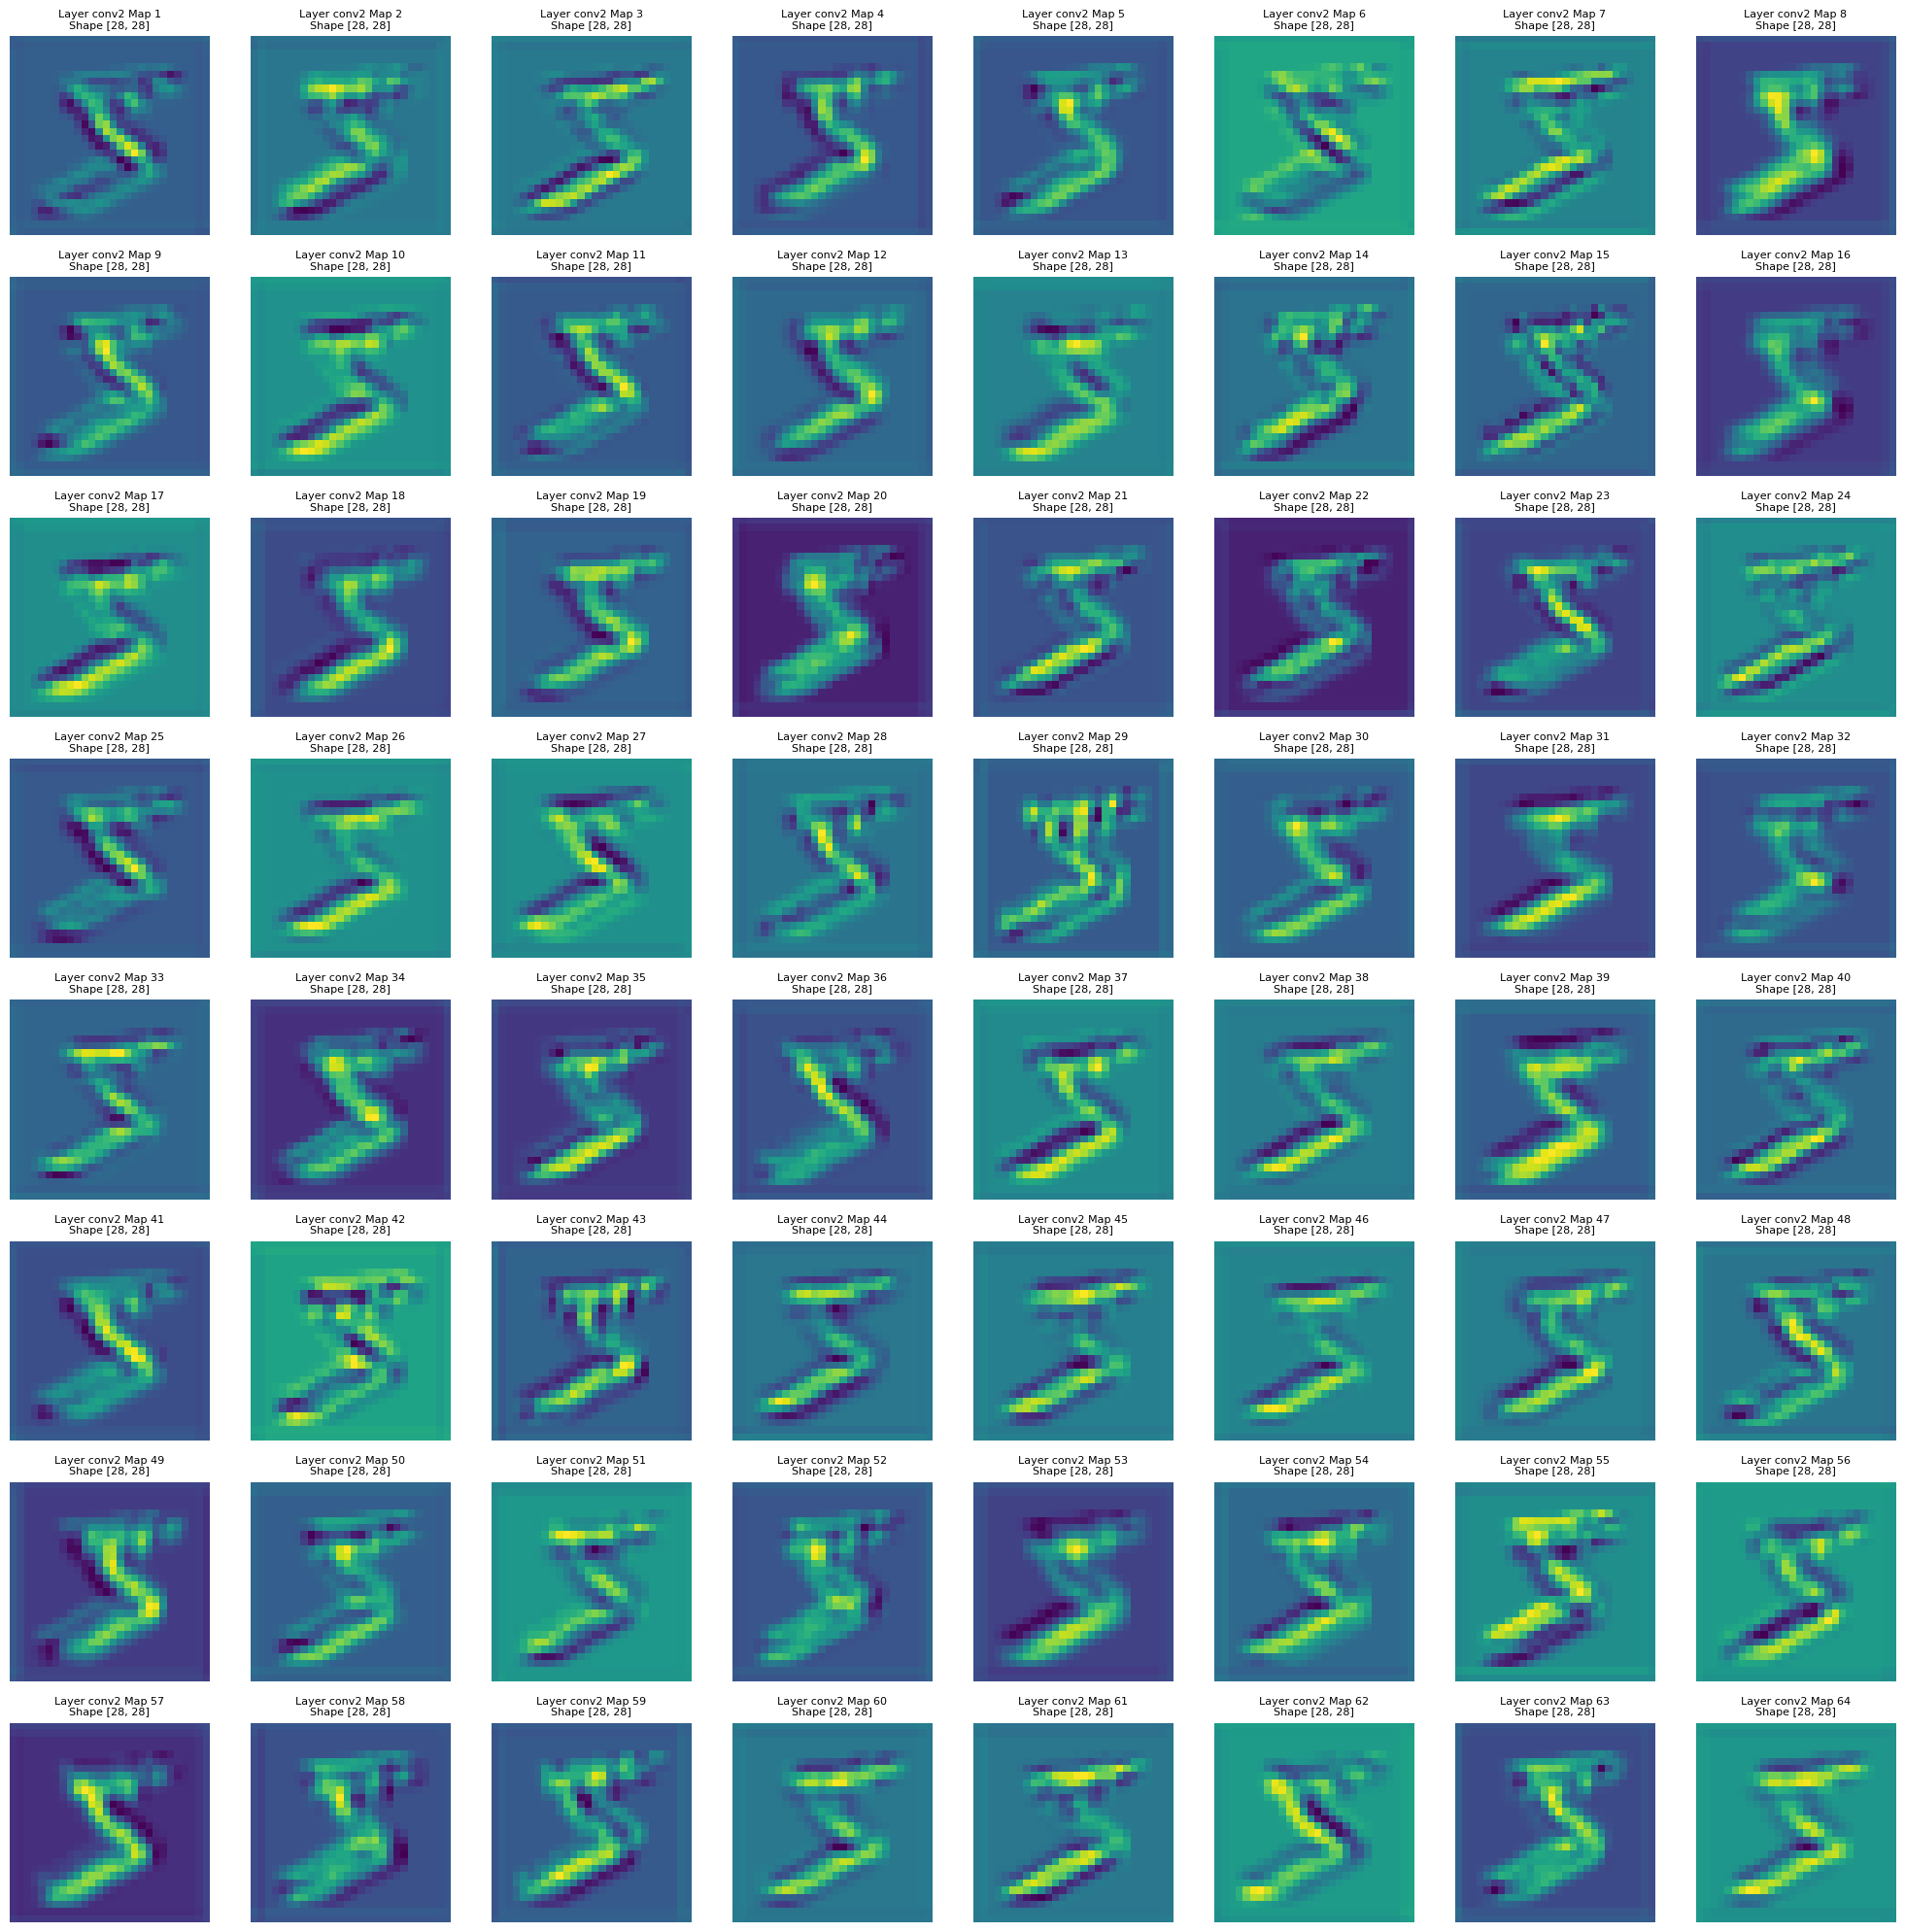

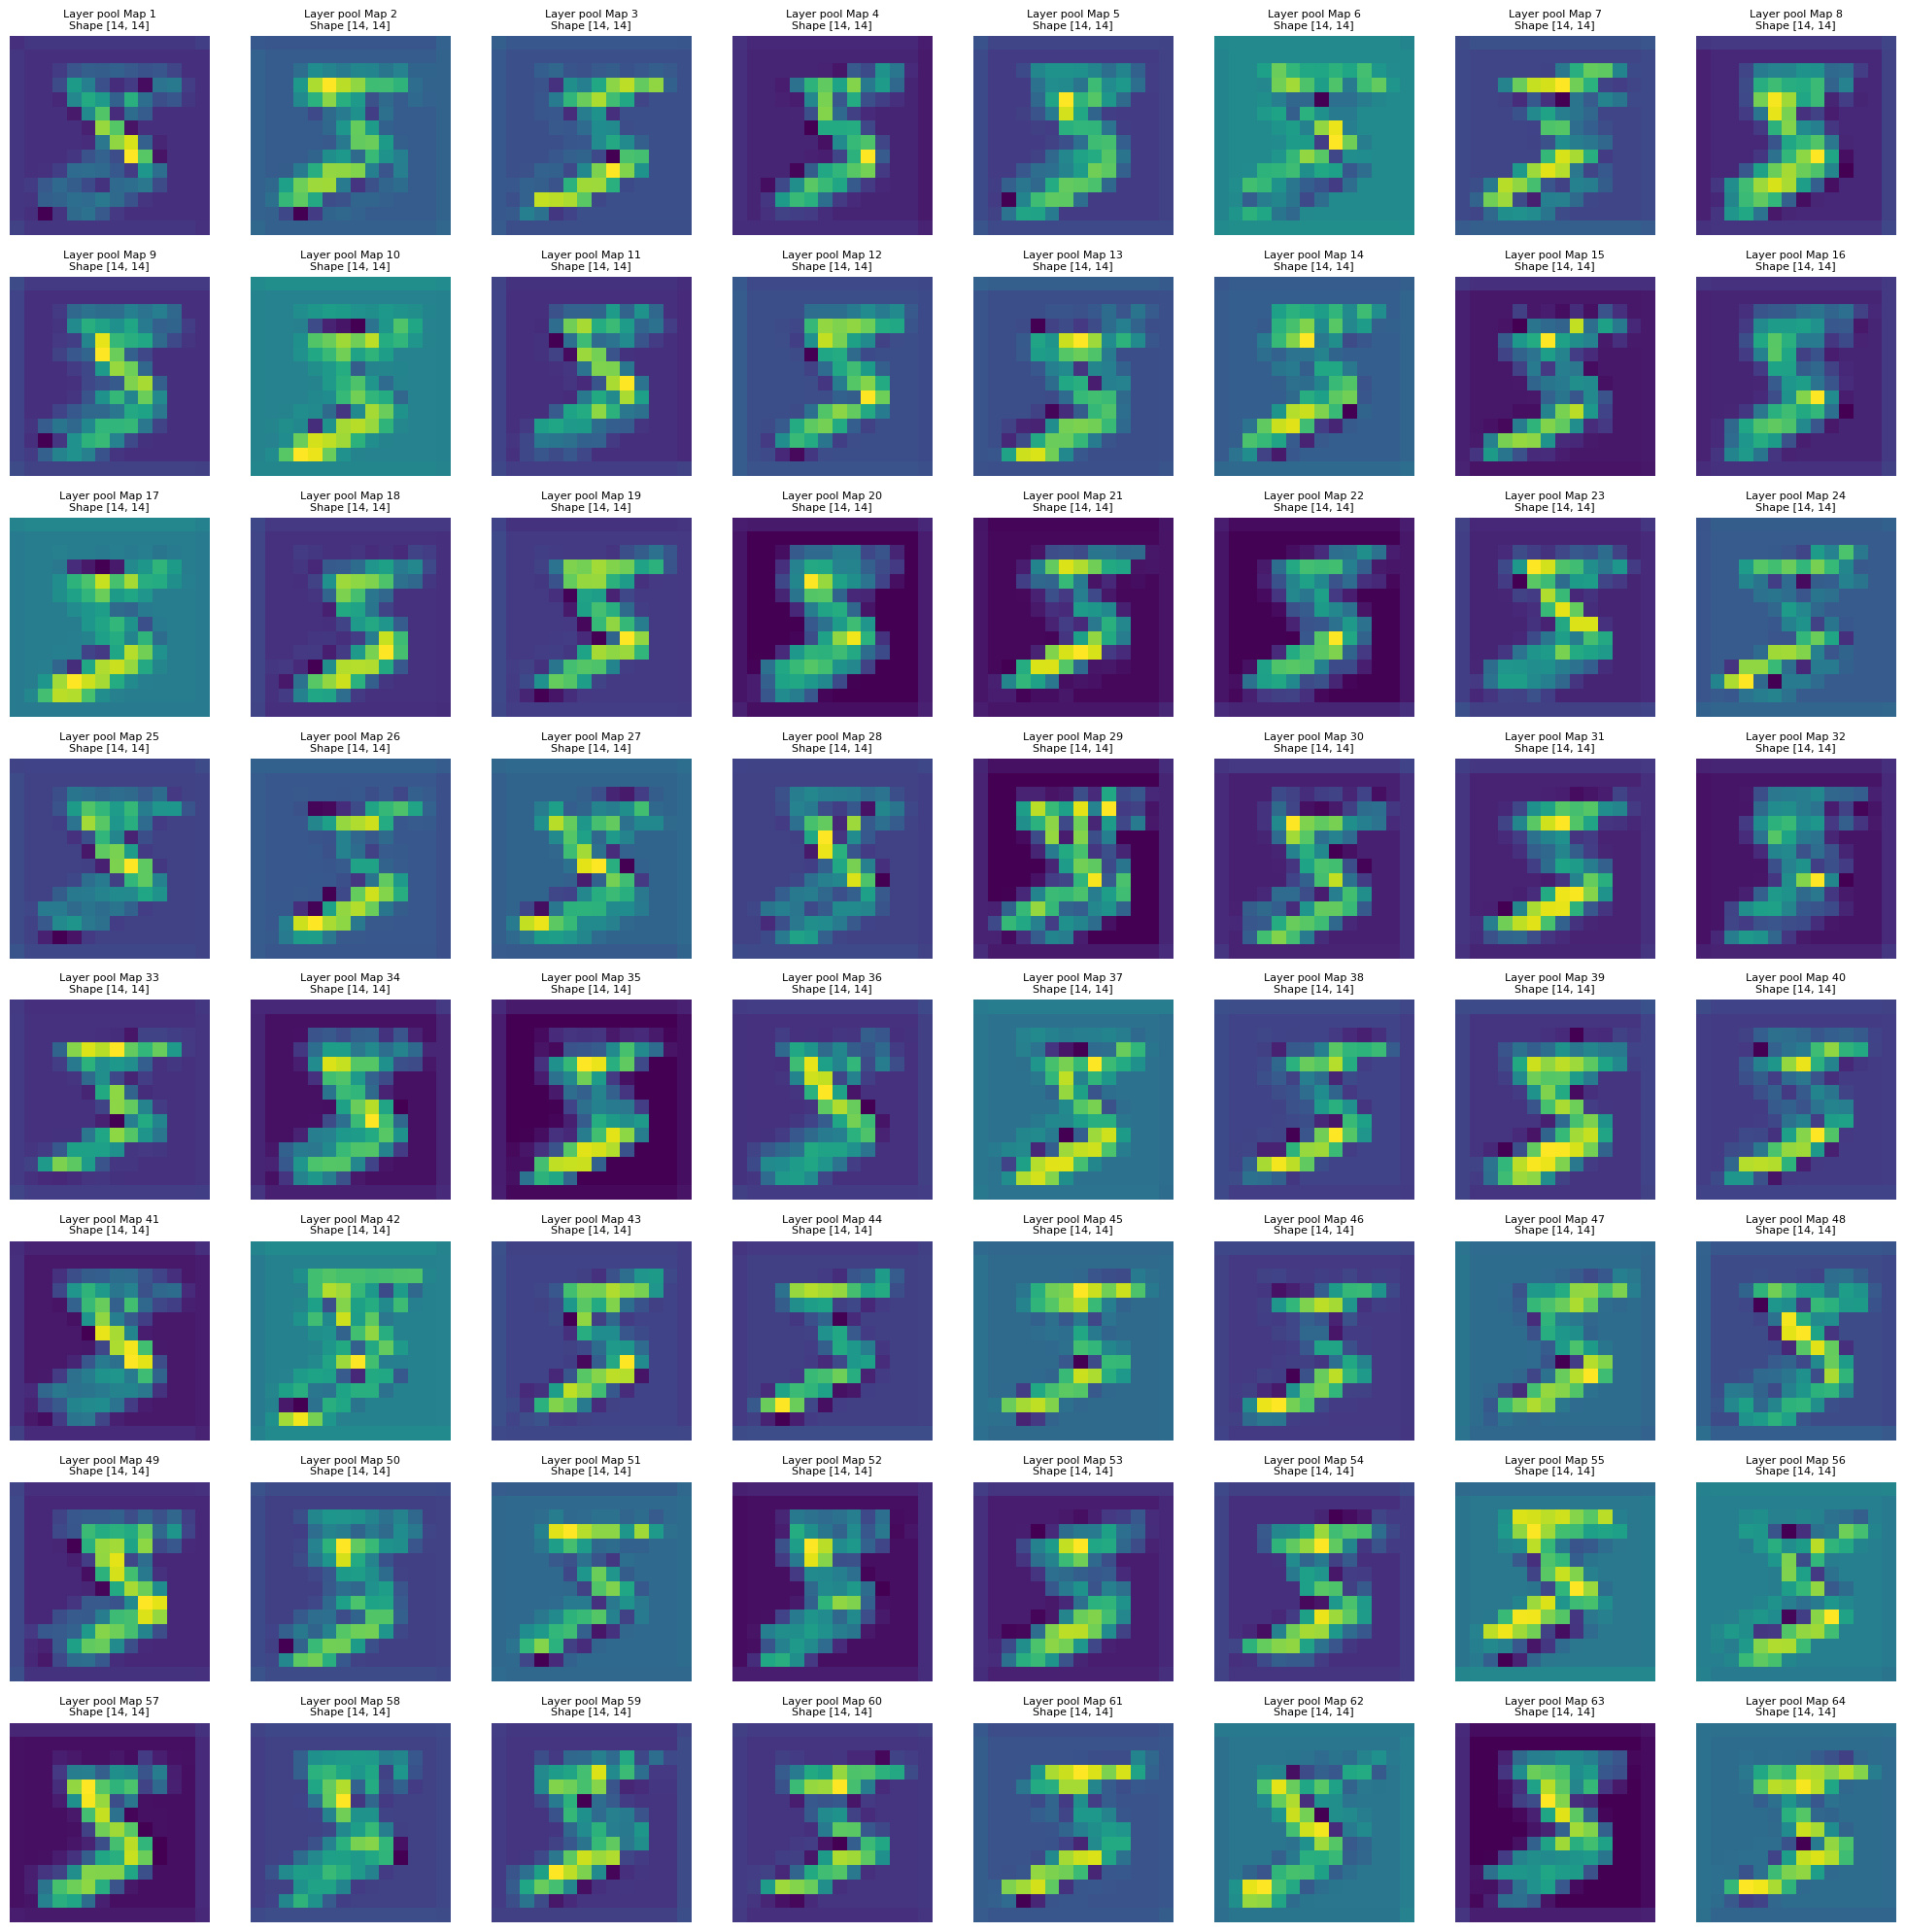

In [6]:
import json
import base64
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# Load JSON
with open("activations.json", "r") as f:
    data = json.load(f)

# ----------------------------
# View CNN summary
# ----------------------------
print("Predicted class:", data["predicted_class"])
print("\nCNN Summary:")
for layer in data["cnn_summary"]:
    print(f"{layer['layer']} | {layer['type']} | Input: {layer['input_shape']} | Output: {layer['output_shape']} | Kernel: {layer['kernel']} | Stride: {layer['stride']} | Padding: {layer['padding']}")

# ----------------------------
# View input image
# ----------------------------
input_base64 = data["input_image_base64"]
input_bytes = base64.b64decode(input_base64)
input_img = Image.open(BytesIO(input_bytes))

plt.figure(figsize=(3,3))
plt.imshow(input_img, cmap='gray')
plt.title("Input Image")
plt.axis('off')
plt.show()

# ----------------------------
# View feature maps
# ----------------------------
def show_feature_maps(fmaps_dict, layer_name, n_cols=8):
    """
    fmaps_dict: dict of feature maps, each map is a dict with keys 'shape' and 'base64'
                e.g., {1: {"shape": [...], "base64": "..."}, 2: {...}, ...}
    layer_name: string, name of the convolution layer (e.g., "conv1")
    """
    # Convert dict to sorted list based on map_index
    sorted_maps = [fmaps_dict[k] for k in sorted(fmaps_dict.keys())]

    n_maps = len(sorted_maps)
    n_rows = (n_maps + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2.5, n_rows*2.5))
    axes = axes.flatten()

    for i, fmap_dict in enumerate(sorted_maps):
        try:
            # Decode and display the image
            img_data = base64.b64decode(fmap_dict["base64"])
            img = Image.open(BytesIO(img_data))
            axes[i].imshow(img, cmap="viridis")
            axes[i].axis("off")

            # Add metadata as title
            map_index = fmap_dict.get('map_index', i+1)
            shape = fmap_dict.get('shape', '?')
            axes[i].set_title(f"Layer {layer_name} Map {map_index}\nShape {shape}", fontsize=8)
        except Exception as e:
            axes[i].axis("off")
            axes[i].set_title("Error", fontsize=6, color="red")
            print(f"Failed to decode map {i+1}: {e}")

    # Hide any unused subplots
    for j in range(len(sorted_maps), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()





# Example: show conv1 feature maps
print(data["feature_maps"].keys())
show_feature_maps(data["feature_maps"]["conv1"], "conv1")
show_feature_maps(data["feature_maps"]["conv2"], "conv2")
show_feature_maps(data["feature_maps"]["pool"], "pool")
# show_feature_maps(data["feature_maps"]["dropout1"], "dropout1")
# show_feature_maps(data["feature_maps"]["fc1"], "fc1")
# show_feature_maps(data["feature_maps"]["dropout2"], "dropout2")
# show_feature_maps(data["feature_maps"]["relu"], "relu")


